## Identifiability of the fitted Transfer Function parameters -- RS

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

---
### What this notebook is for

A fitting search returns the best few parameter sets. This notebook asks whether
those parameter sets mean anything individually, or whether only the surface they
produce is meaningful. It is a diagnostic to run after fitting, before the fitted
coefficients are reported or reused.

It answers four questions:

1. **How many distinct solutions are there really?** (Section 2) The retained fits
   may be a handful of basins sampled repeatedly rather than independent draws. This
   sets the effective sample size for everything that follows.
2. **Which coefficients are constrained by the data?** (Sections 1, 6, 7) A stiff
   coefficient is pinned; a sloppy one is free. Only the stiff ones can be compared
   across neuron models or reported as fitted values.
3. **Do the retained fits produce different transfer functions?** (Section 8) If not,
   the coefficient spread is not an uncertainty and should not be reported as one.
4. **Where does the fit fail?** (Section 8) That region bounds the domain of validity
   of the mean-field model built from it.

Section 10 prints a report summarising all four.

**To run this for another population**, change `neuron_model` in the configuration
cell. Nothing else in the notebook is population-specific.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..',))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Plots_helper import *
from ntmf.analysis_helper import *
from ntmf.transfer_function import *
from ntmf.config import get_params_model_SI, get_network_config, adding_K_params

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

In [4]:
# ============================================================== #
#  CONFIGURATION
#  This is the ONLY cell that differs between the FS, RS and
#  RS_no_adapt versions of this notebook. Everything below is
#  identical by construction.
# ============================================================== #
neuron_model = 'RS'          # 'FS' | 'RS' | 'RS_no_adapt'

# --- paths --------------------------------------------------- #
results_file       = f'../fitting/results/10_best_params_TF_{neuron_model}.json'
neuron_json        = f'../../neuron_models/AdEx/{neuron_model}.json'
network_config_dir = '../../config/'
network_file_name  = 'network_config_file_v0.json'
simulation_folder  = f'../data_extraction/simulations/TF_{neuron_model}_delay_v1'
data_file          = f'testing_TF_data_{neuron_model}.dat'

fig_name = f'Analysing_TF_fitted_params_{neuron_model}'

# --- analysis options ---------------------------------------- #
STANDARDIZE = True     # PCA on the z-scored coefficients (see Section 7)
N_CLUSTERS  = 'auto'   # or an int to force the cluster count
MIN_FREQ    = 5        # input range retained
MAX_FREQ    = 15
REL_FLOOR   = 1.0      # mask the relative error below this rate (Hz)

params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2',
               'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

# --- RS only ------------------------------------------------- #
# RS is the adaptive population. The simulations use delay = 1 s to discard the
# onset transient, so the data below are the stationary rates and TF_template is
# called without an explicit adaptation argument, exactly as for FS.
# >> VERIFY this matches your ntmf.transfer_function signature. If your
#    TF_template takes w_ad, pass the stationary value here.


In [5]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig)

In [6]:
# Load
with open(results_file, 'r') as f:
    data = json.load(f)

alphas      = np.array([d['alpha'] for d in data])
errors      = np.array([d['mean_error'] for d in data])
poly_params = np.array([d['polynomial_params'] for d in data])

n_models, n_params = poly_params.shape
print(f'{neuron_model}: {n_models} retained fits, {n_params} coefficients')

means  = poly_params.mean(axis=0)
stds   = poly_params.std(axis=0, ddof=1)
poly_z = (poly_params - means) / stds

RS: 10 retained fits, 10 coefficients


---
## 1. Stiff and sloppy coefficients

Ranked by coefficient of variation. A low CV means the data pin the coefficient; a
CV above ~100% means its standard deviation exceeds its own mean, i.e. the fit is
essentially free to choose it.

**What to look for:** if only one or two coefficients have a low CV, the fitted
values of the rest are not reportable quantities.

In [7]:
df_stats = coefficient_stats(poly_params, params_name)
print(df_stats.to_string(index=False))

 param_id params_name      mean      std       cv
        0         P_0 -0.049391 0.000240 0.004865
        1        P_mu  0.007157 0.000095 0.013205
        2       P_sig  0.013776 0.000446 0.032405
        4       P_mu2  0.000396 0.000013 0.032920
        5      P_sig2  0.004590 0.000293 0.063731
        8    P_mu_tau  0.002935 0.000233 0.079366
        7    P_mu_sig -0.000554 0.000105 0.189214
        3       P_tau -0.002859 0.000602 0.210639
        9   P_sig_tau  0.003023 0.000925 0.306100
        6      P_tau2  0.000804 0.000280 0.348514


---
## 2. How many distinct solutions?

The retained fits are the lowest-error entries of a search. They may all be the same
basin sampled repeatedly, or they may be several distinct basins that happen to score
similarly. This matters before anything else: **the effective sample size is the
number of clusters, not the number of rows**, and every correlation and p-value below
is computed over the rows.

Branches are found by Ward clustering of the z-scored coefficients, with the count
chosen by silhouette score. Inspect the third panel and override `N_CLUSTERS` in the
configuration cell if the automatic choice looks wrong.

In [8]:
labels, cluster_diag = detect_clusters(poly_params, n_clusters=N_CLUSTERS)
n_detected = len(np.unique(labels))

print('Silhouette by candidate cluster count:')
print(cluster_diag.to_string(index=False))
print(f'\n-> {n_detected} cluster(es) detected.')

Silhouette by candidate cluster count:
 n_clusters  silhouette
          2    0.224200
          3    0.169318
          4    0.174790

-> 1 cluster(es) detected.


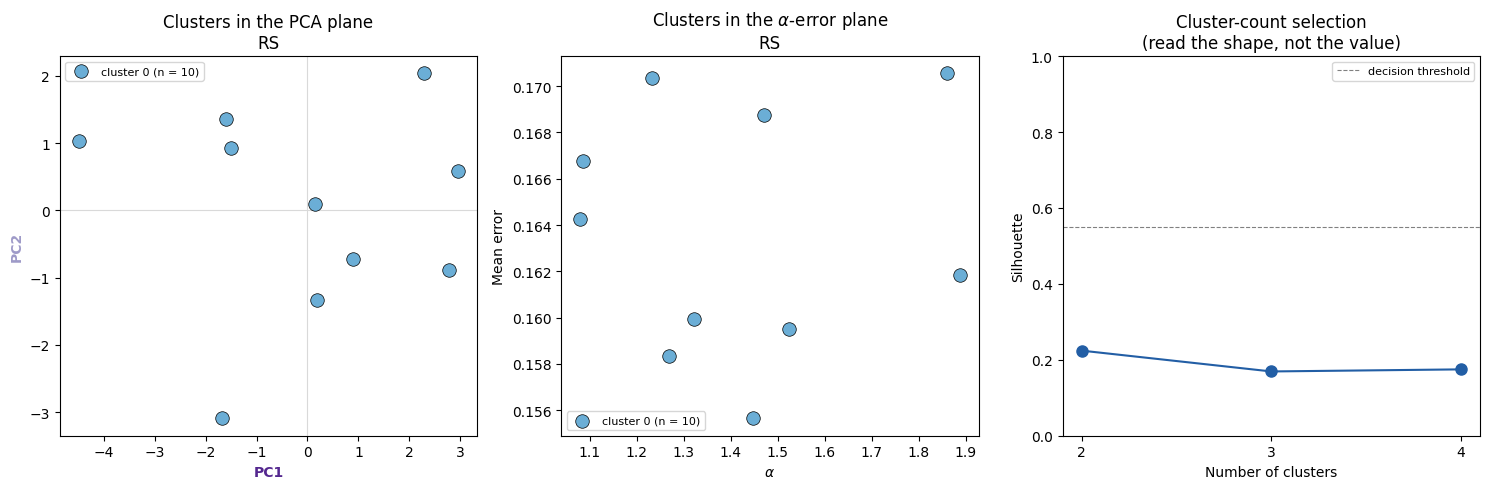

In [9]:
pca_tmp = PCA().fit(poly_z if STANDARDIZE else poly_params)
X_tmp   = pca_tmp.transform(poly_z if STANDARDIZE else poly_params)

fig = plot_clusters(neuron_model, alphas, errors, labels, X_tmp, cluster_diag)
figs.append(fig)

In [10]:
if n_detected > 1:
    summary, coeff_means = cluster_summary(labels, alphas, errors, poly_params, params_name)
    print(summary.to_string(index=False))
    print()
    print(coeff_means.to_string(index=False))
else:
    print('Single cluster: the retained fits are one basin sampled repeatedly.')

Single cluster: the retained fits are one basin sampled repeatedly.


**How to read this.** If more than one cluster is found, check three things.

- *Do coefficients change sign between clusters?* Then the clusters are not
  neighbouring solutions and averaging across them is meaningless.
- *Does the error separate the clusters by much?* If the clusters score within a few
  percent of each other, the objective cannot distinguish them and the ranking that
  produced the top-N is close to arbitrary.
- *Does alpha still predict the error within a cluster?* If not, alpha is not the
  underlying variable -- it is just another coordinate that differs between basins.

---
## 3. Dependence on $\alpha$

Whether the coefficients are independent degrees of freedom or are slaved to $\alpha$
through the fit. A high $R^2$ of the trend in $\alpha$ means the latter.

**Read this together with Section 2.** A smooth trend and a step both give a high
$R^2$ but mean different things: a trend is a continuous degeneracy, a step is two
basins. The `R2_step` column below distinguishes them.

In [11]:
trend_df = alpha_trend(alphas, poly_params, params_name, deg=2)
print(trend_df.to_string(index=False))

params_name   r_alpha  p_alpha  R2_deg2_alpha
        P_0  0.977045 0.000001       0.954634
       P_mu  0.958249 0.000013       0.958181
      P_sig  0.712058 0.020878       0.596690
      P_tau  0.325078 0.359394       0.134134
      P_mu2 -0.850983 0.001795       0.757417
     P_sig2 -0.573533 0.083015       0.470296
     P_tau2  0.314571 0.376022       0.120945
   P_mu_sig  0.460739 0.180210       0.302880
   P_mu_tau -0.770482 0.009106       0.595511
  P_sig_tau -0.623278 0.054199       0.533251


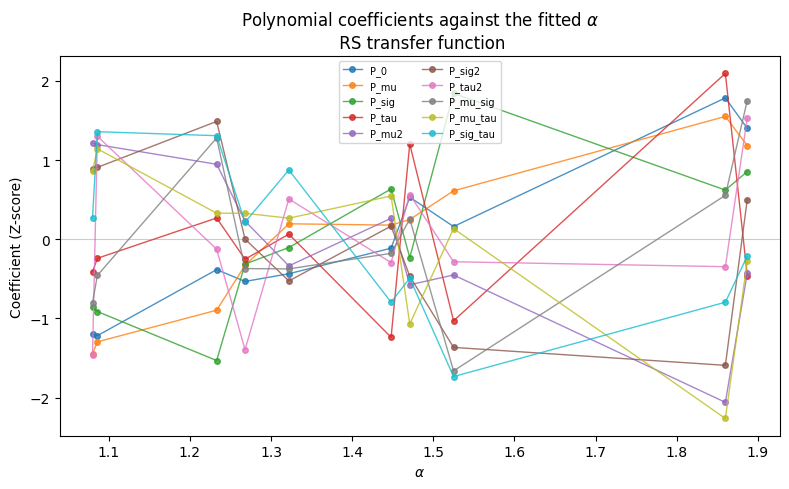

In [12]:
fig = plot_coefficients_vs_alpha(neuron_model, alphas, poly_z, params_name)
figs.append(fig)

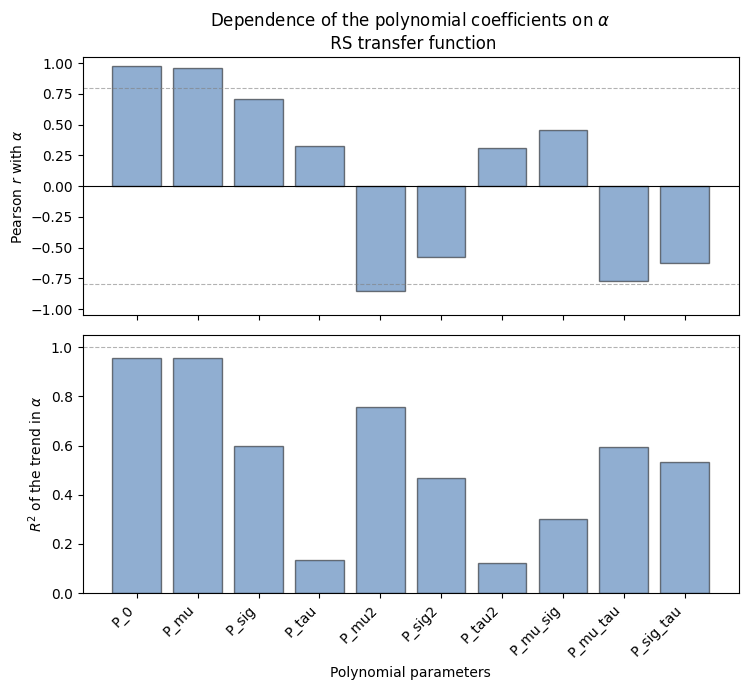

In [13]:
fig = plot_alpha_trend(neuron_model, trend_df)
figs.append(fig)

 alpha  mean_error  cluster
 1.080    0.164265        0
 1.086    0.166745        0
 1.233    0.170337        0
 1.268    0.158324        0
 1.322    0.159955        0
 1.448    0.155645        0
 1.471    0.168772        0
 1.525    0.159492        0
 1.860    0.170550        0
 1.887    0.161857        0


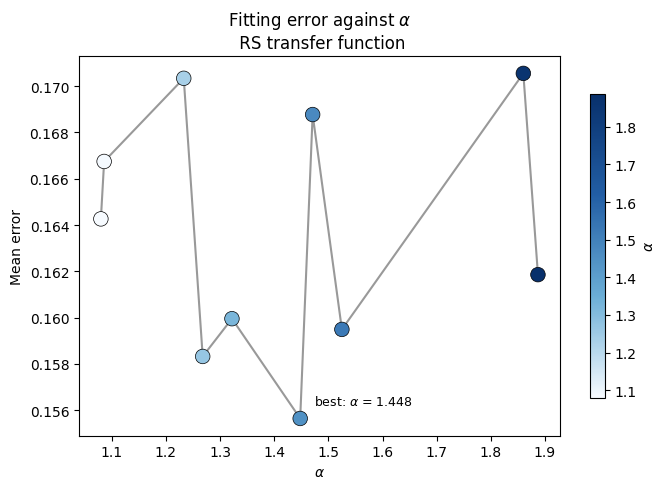

In [14]:
fig = plot_error_vs_alpha(neuron_model, alphas, errors)
figs.append(fig)

order = np.argsort(alphas)
print(pd.DataFrame({'alpha': alphas[order],
                    'mean_error': errors[order],
                    'cluster': labels[order]}).to_string(index=False))

---
## 4. Spread of the coefficients

The violin outline is a kernel density estimate of very few samples; only the
overlaid points should be read quantitatively. If Section 2 found clusters, this
spread is the between-cluster difference, not a distribution.

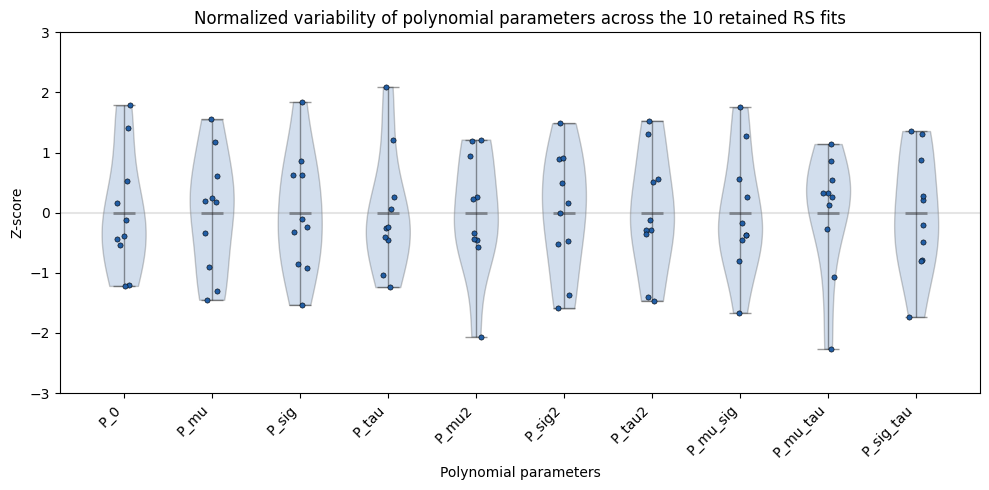

In [15]:
fig = plot_violin(neuron_model, poly_z, params_name)
figs.append(fig)

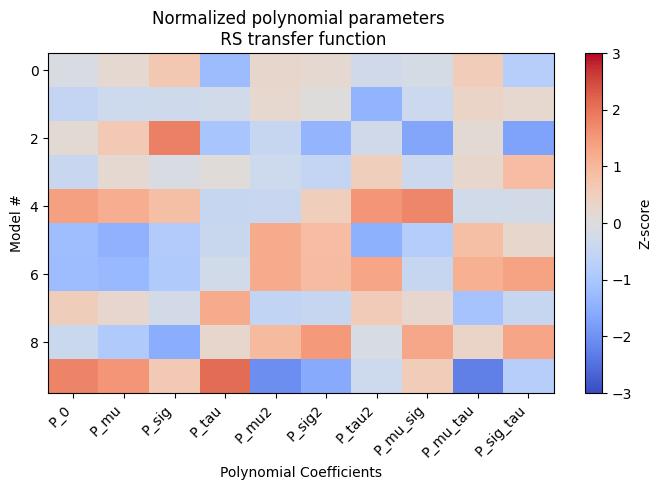

In [16]:
fig = plot_poly_zscore_heatmap(neuron_model, poly_z, params_name)
figs.append(fig)

---
## 5. Correlation with the fitting error

> **Caveat.** These correlations are computed over the retained fits. If Section 2
> found more than one cluster, the effective sample size is the cluster count and the
> p-values below are not valid -- they are reporting a two-group difference as a
> correlation over N independent draws. Read the sign, ignore the p-value.

In [17]:
corr_df = correlation_with_error(poly_params, errors, alphas, params_name, deg=1)
print(corr_df.to_string(index=False))

if n_detected > 1:
    print(f'\n*** {n_detected} clusters detected: effective n = {n_detected}, not {n_models}.')
    print('    The p-values above are not valid. ***')

params_name     r_raw    p_raw  r_partial  p_partial
        P_0  0.211617 0.557267   0.832857   0.002776
       P_mu -0.083054 0.819567  -0.408374   0.241345
      P_sig -0.474226 0.166131  -0.711464   0.021034
      P_tau  0.783074 0.007387   0.816483   0.003951
      P_mu2 -0.121542 0.738020  -0.174645   0.629405
     P_sig2  0.110826 0.760524   0.159967   0.658889
     P_tau2  0.190611 0.597860   0.189288   0.600453
   P_mu_sig  0.424513 0.221408   0.460364   0.180612
   P_mu_tau -0.459289 0.181765  -0.678481   0.031020
  P_sig_tau  0.306436 0.389150   0.420103   0.226759


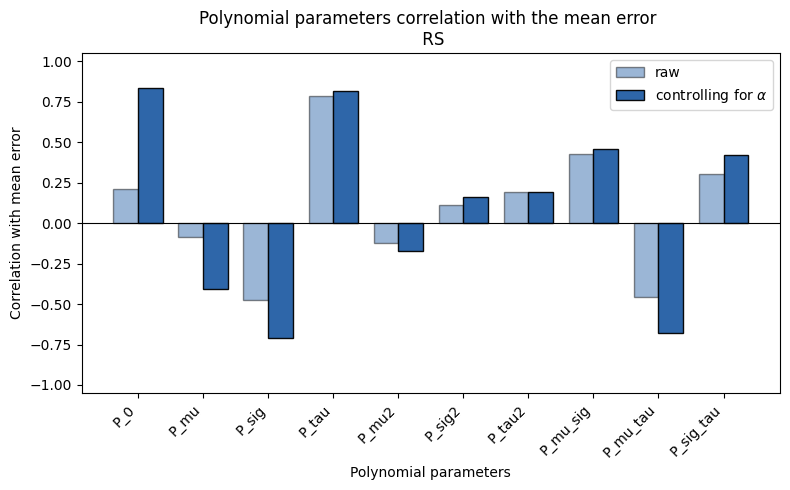

In [18]:
fig = plot_poly_correlation_error(neuron_model, corr_df)
figs.append(fig)

---
## 6. Collinearity between the coefficients

A median $|r|$ close to 1 means the coefficients are not separable: the fit has one
collective mode rather than ten degrees of freedom.

In [19]:
corr_matrix = np.corrcoef(poly_z.T)

coll = collinearity_summary(corr_matrix)
for k, v in coll.items():
    print(f'{k:>24s} : {v:.3f}')

            median_abs_r : 0.500
               min_abs_r : 0.058
               max_abs_r : 0.931
    frac_abs_r_above_0.8 : 0.178


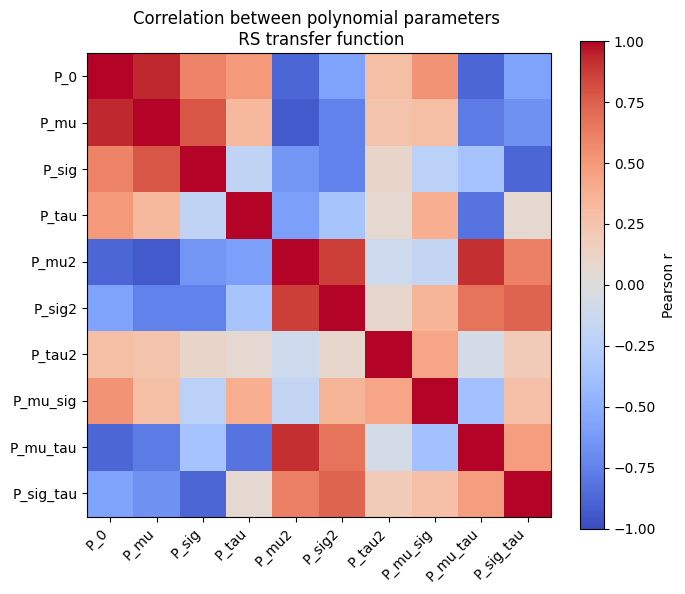

In [20]:
fig = plot_corr_matrix(neuron_model, corr_matrix, params_name)
figs.append(fig)

---
## 7. PCA

In [21]:
# The polynomial coefficients all expand V_thre_eff and are therefore in the same
# units, so a covariance PCA on the raw values is defensible. It is however dominated
# by the highest-variance coefficients, which is a statement about their scale rather
# than about their covariation. STANDARDIZE is set in the configuration cell so the
# choice is documented rather than implicit.
X = poly_z if STANDARDIZE else poly_params

pca = PCA()
X_pca = pca.fit_transform(X)
expl_var = pca.explained_variance_ratio_
cum_var  = np.cumsum(expl_var)

# Only min(n_models - 1, n_params) components can carry variance.
rank_max = min(n_models - 1, n_params)
print(f'n_models = {n_models}, n_params = {n_params}  ->  attainable rank <= {rank_max}')
print(f'PC1 + PC2 explain {cum_var[1] * 100:.2f}% of the variance (standardized = {STANDARDIZE}).')
print()
print(pd.DataFrame({'PC': np.arange(1, rank_max + 1),
                    'expl_var': expl_var[:rank_max],
                    'cum_var': cum_var[:rank_max]}).to_string(index=False))

n_models = 10, n_params = 10  ->  attainable rank <= 9
PC1 + PC2 explain 79.23% of the variance (standardized = True).

 PC     expl_var  cum_var
  1 5.593682e-01 0.559368
  2 2.329070e-01 0.792275
  3 1.284551e-01 0.920730
  4 6.065837e-02 0.981389
  5 1.684156e-02 0.998230
  6 1.604203e-03 0.999834
  7 1.636819e-04 0.999998
  8 1.269535e-06 0.999999
  9 6.118959e-07 1.000000


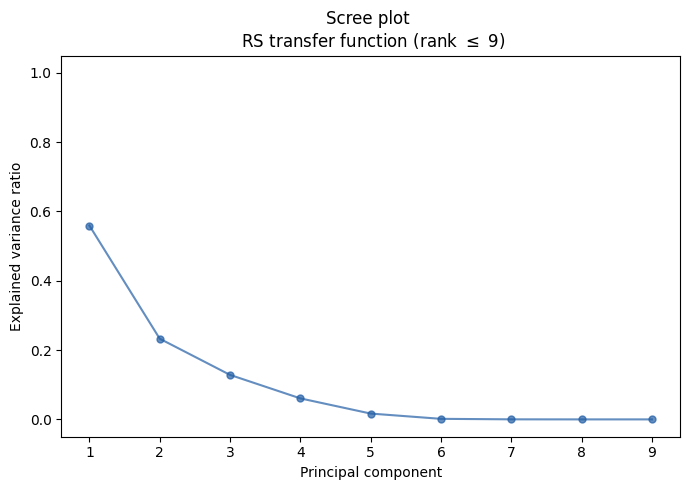

In [22]:
fig = plot_scree(neuron_model, expl_var, n_models=n_models)
figs.append(fig)

In [23]:
loadings_values = pd.DataFrame(pca.components_[:2], columns=params_name, index=['PC1', 'PC2'])
print(loadings_values.to_string())

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  P_mu_sig  P_mu_tau  P_sig_tau
PC1 -0.390945 -0.405060 -0.311247 -0.207341  0.413959  0.354605 -0.059143 -0.078398  0.376494   0.307774
PC2  0.182090  0.013242 -0.364311  0.404242 -0.041129  0.253836  0.304240  0.565739 -0.215254   0.381383


### What is PC1?

The loadings say which coefficients move together, not why. Two checks before
assigning any meaning:

- **Uniform loadings.** If every magnitude is close to $1/\sqrt{n_{params}}$, PC1 is
  the direction in which all coefficients move as one rigid block. There is one
  collective mode, not a structured mode.
- **What does PC1 track?** Correlate the scores with $\alpha$, with the error, and
  with the cluster label. Whichever wins is what PC1 *is*.

In [24]:
uni = 1 / np.sqrt(n_params)
mags = np.abs(pca.components_[0])
print(f'PC1 loading magnitudes: min = {mags.min():.3f}, max = {mags.max():.3f}')
print(f'uniform would be 1/sqrt({n_params}) = {uni:.3f}')
print(f'-> {"rigid block: all coefficients move together" if mags.min() > 0.7 * uni else "structured: some coefficients dominate"}')
print()

for k in range(2):
    r_a, p_a = pearsonr(X_pca[:, k], alphas)
    r_e, p_e = pearsonr(X_pca[:, k], errors)
    print(f'PC{k+1}:  r(score, alpha) = {r_a:+.3f} (p = {p_a:.4f})   '
          f'r(score, error) = {r_e:+.3f} (p = {p_e:.4f})')

if n_detected > 1:
    from scipy.stats import pointbiserialr
    for k in range(2):
        r_b, p_b = pointbiserialr((labels > 0).astype(int), X_pca[:, k])
        print(f'PC{k+1}:  r(score, cluster) = {r_b:+.3f} (p = {p_b:.5f})')

PC1 loading magnitudes: min = 0.059, max = 0.414
uniform would be 1/sqrt(10) = 0.316
-> structured: some coefficients dominate

PC1:  r(score, alpha) = -0.910 (p = 0.0003)   r(score, error) = -0.084 (p = 0.8181)
PC2:  r(score, alpha) = +0.155 (p = 0.6690)   r(score, error) = +0.704 (p = 0.0232)


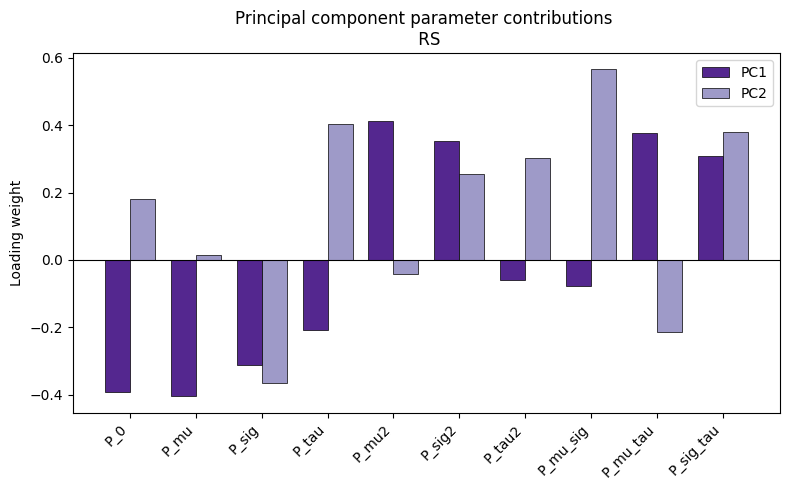

In [25]:
fig = plot_pca_parameter_contributions(neuron_model, loadings_values.loc['PC1'],
                                      loadings_values.loc['PC2'])
figs.append(fig)

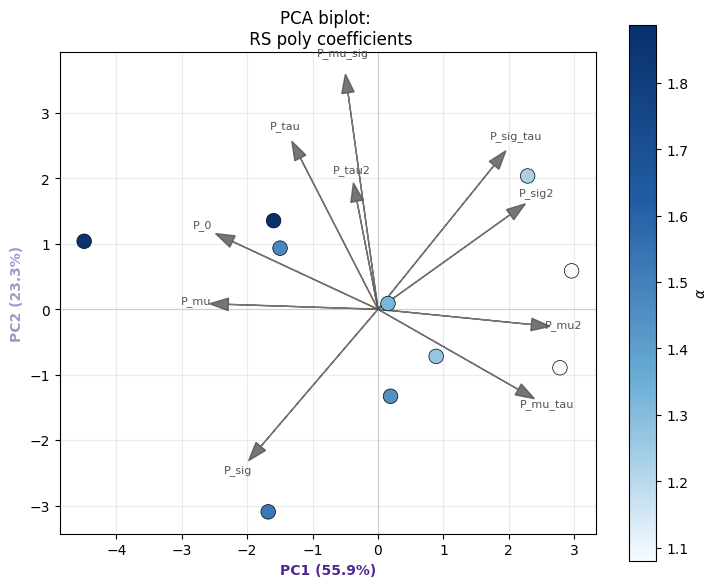

In [26]:
fig = plot_pca_biplot(neuron_model, params_name, X_pca, pca.components_, expl_var,
                      color_by=alphas, color_by_label=r'$\alpha$')
figs.append(fig)

---
## 8. Are the retained fits distinguishable, and where does the fit fail?

The decisive section. Coefficients may scatter widely and still produce the same
transfer function. And the region where the fit fails bounds the domain over which the
resulting mean-field model can be trusted.

In [27]:
params_SI = get_params_model_SI(neuron_model = neuron_model,
                                json_file_name = neuron_json)

network_config = get_network_config(
    json_file_name = os.path.join(network_config_dir, network_file_name))

params_SI = adding_K_params(neuron_params = params_SI,
                            network_config = network_config)

In [28]:
# --- Load the simulated transfer-function data ---
df_data = pd.read_csv(os.path.join(simulation_folder, data_file),
                      sep=r'\s+', header=0)

x_s = np.array(sorted(df_data['input_exc'].unique()))
y_s = np.array(sorted(df_data['input_inh'].unique()))

x_mask = (x_s >= MIN_FREQ) & (x_s <= MAX_FREQ)
y_mask = (y_s >= MIN_FREQ) & (y_s <= MAX_FREQ)   # FIX: was built from x_s
x_s_sel, y_s_sel = x_s[x_mask], y_s[y_mask]

df_data = df_data[
    (df_data['input_exc'] >= MIN_FREQ) & (df_data['input_exc'] <= MAX_FREQ) &
    (df_data['input_inh'] >= MIN_FREQ) & (df_data['input_inh'] <= MAX_FREQ)
].copy()

inh_vals = y_s_sel
print(f'grid: {len(x_s_sel)} exc x {len(y_s_sel)} inh = {len(df_data)} points')

grid: 21 exc x 21 inh = 441 points


In [29]:
fit_cols = []
for alpha_idx in range(len(alphas)):
    col = f'fit_rate_alpha_{alpha_idx}'
    fit_cols.append(col)
    df_data[col] = TF_template(data=df_data, params=params_SI,
                               poly_params=poly_params[alpha_idx],
                               alpha=alphas[alpha_idx])

unique_inh = np.sort(df_data['input_inh'].unique())
best_idx = int(np.argmin(errors))
best_col = fit_cols[best_idx]
print(f'best fit: index {best_idx}, alpha = {alphas[best_idx]:.3f}, '
      f'error = {errors[best_idx]:.3f}')

best fit: index 0, alpha = 1.448, error = 0.156


Ensemble std across fits: median = 0.042 Hz, max = 0.079 Hz
Simulated std of nu_out : median = 2.150 Hz
Fits indistinguishable on 100.0% of the grid


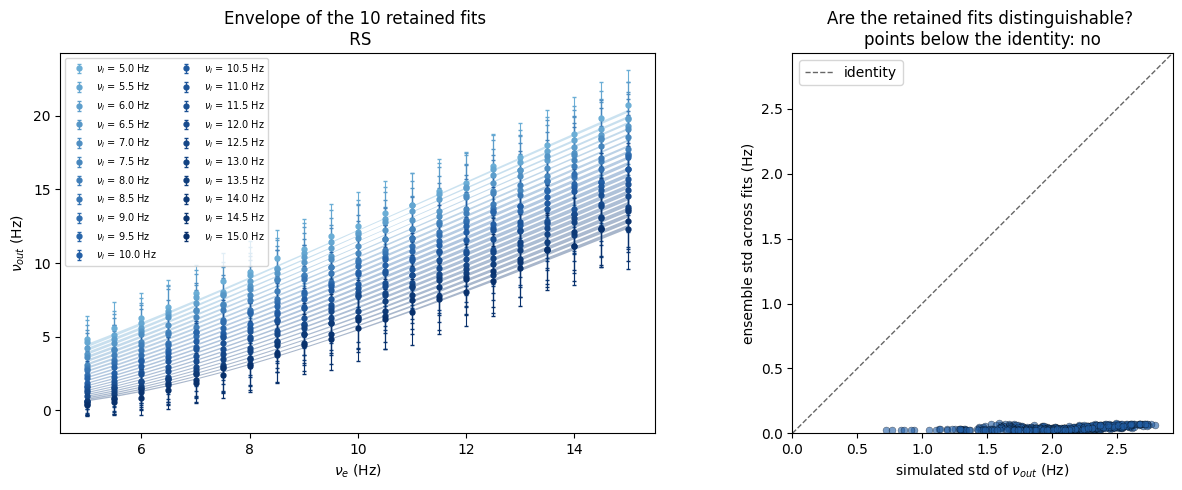

In [30]:
fig, ensemble_std = plot_TF_ensemble_envelope(neuron_model, df_data, fit_cols, unique_inh)
figs.append(fig)

sim_std = df_data['std_f_out'].to_numpy()
envelope_frac = float(np.mean(ensemble_std < sim_std))

print(f'Ensemble std across fits: median = {np.median(ensemble_std):.3f} Hz, '
      f'max = {ensemble_std.max():.3f} Hz')
print(f'Simulated std of nu_out : median = {np.median(sim_std):.3f} Hz')
print(f'Fits indistinguishable on {envelope_frac * 100:.1f}% of the grid')

Below the identity line the ensemble spread is smaller than the noise in the data, so
the retained fits cannot be told apart there. If that fraction is not close to 100%,
the next two figures locate the disagreement.

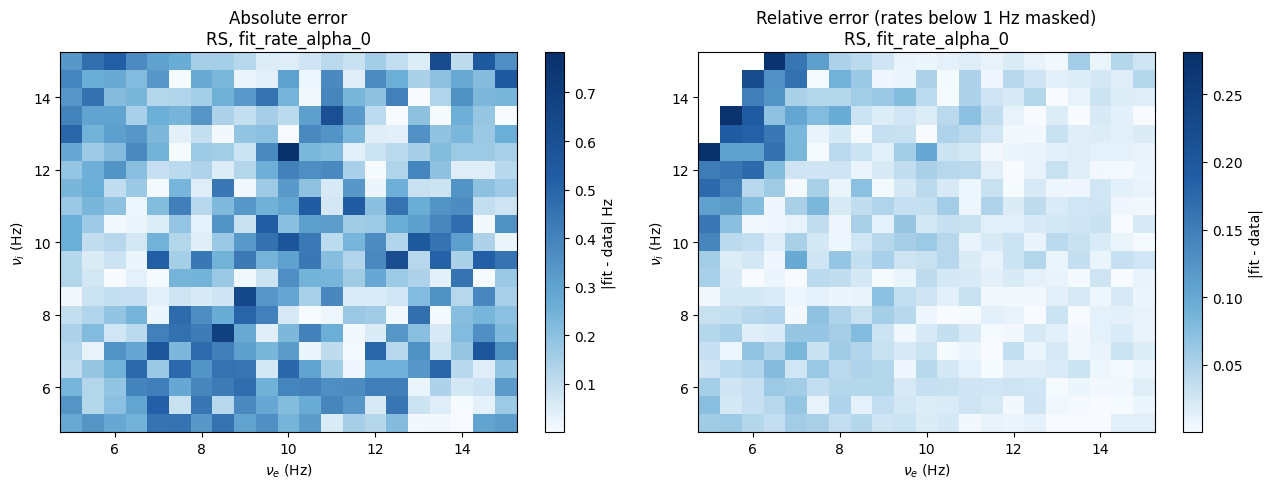

In [31]:
fig = plot_TF_error_map(neuron_model, df_data, best_col, rel_floor=REL_FLOOR)
figs.append(fig)

Inhibitory levels contributing most to the total error:
 input_inh  mean_err  mean_rate  share_of_total
       6.0  0.295655  11.897619        0.061041
       9.5  0.292550   9.442381        0.060400
       6.5  0.269706  11.535238        0.055684
       7.0  0.268191  11.185714        0.055371
      11.0  0.258362   8.404762        0.053342

Top 3 levels account for 17.7% of the total error.


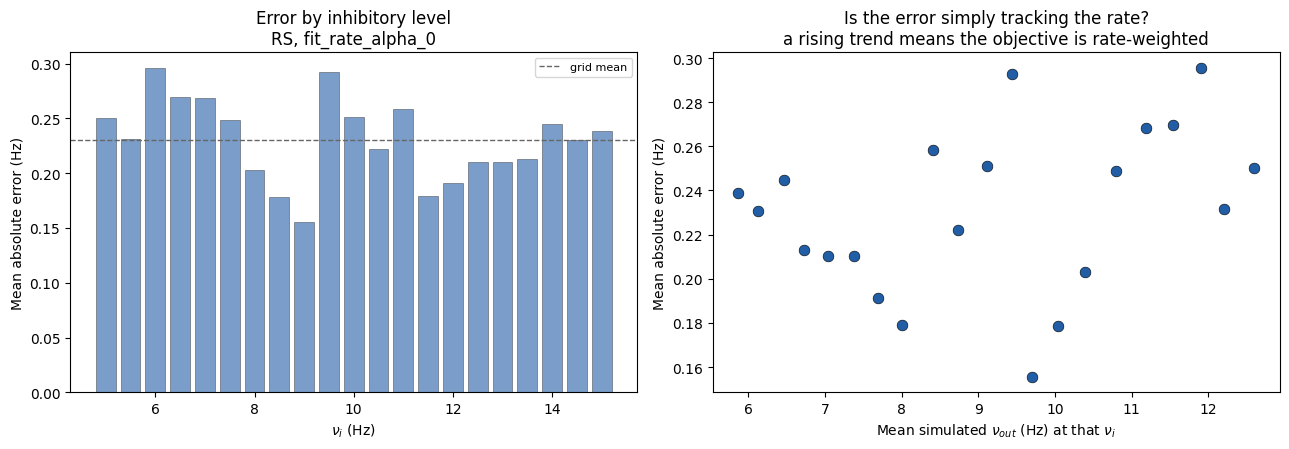

In [32]:
fig, contribution = plot_error_by_inhibition(neuron_model, df_data, best_col)
figs.append(fig)

top = contribution.sort_values('share_of_total', ascending=False).head(5)
print('Inhibitory levels contributing most to the total error:')
print(top.to_string(index=False))

print(f"\nTop 3 levels account for "
      f"{100 * top['share_of_total'].head(3).sum():.1f}% of the total error.")

**How to read the last two figures.** The objective is a mean absolute error in Hz, so
it is dominated by wherever the output rate is largest, regardless of whether that
region matters for the network the mean-field model will be used in. If a few rows of
the grid carry most of the error, then the ranking that produced the top-N fits was
decided there, and:

- consider restricting the fitting domain to the region the network actually visits;
- consider a relative error, or a variance-stabilising transform ($\sqrt{\nu}$ or
  $\log(1+\nu)$), which rebalances the objective without hand-tuned weights;
- either way, report the resulting domain of validity.

---
## 9. Error distribution across inhibitory input

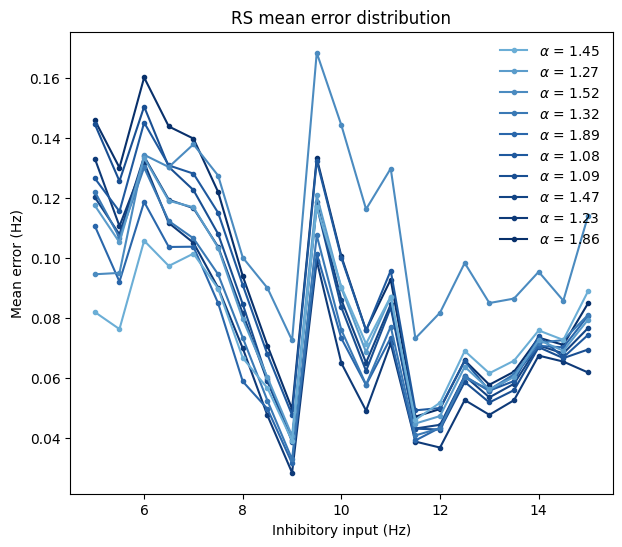

In [33]:
fig, ax = plt.subplots(figsize=(7, 6))
for alpha_idx in reversed(range(len(alphas))):
    distr_mean_error = get_mean_error_distribution(neuron_model, df_data,
                                                   poly_params[alpha_idx], params_SI,
                                                   alphas[alpha_idx], unique_inh,
                                                   alpha_idx=alpha_idx)
    fig = plots_TF_distr_mean_error(neuron_model, inh_vals, distr_mean_error,
                                    alpha=alphas[alpha_idx],
                                    alpha_idx=alpha_idx, n_alphas=len(alphas),
                                    ax=ax)
figs.append(fig)

---
## 10. Report

In [34]:
diagnostic_report(neuron_model, poly_params, alphas, errors, params_name,
                  labels=labels, expl_var=expl_var, envelope_frac=envelope_frac)

  IDENTIFIABILITY REPORT  --  RS   (10 retained fits)

  Error range          : 0.156 - 0.171 (9.6% spread)
  Alpha range          : 1.080 - 1.887

  Stiffest coefficient : P_0 (CV = 0.5%)
  Sloppiest            : P_tau2 (CV = 35%)
  Collinearity         : median |r| = 0.50, 18% of pairs above 0.8
  Effective dimension  : 4 PC(s) reach 95% of the variance (PC1 alone = 55.9%)

  Clusters detected    : 1
     The ensemble is a single basin sampled repeatedly.

  Fits indistinguishable on 100.0% of the input grid

  Reading: high collinearity + one dominant PC means the fitted
  coefficients are not individually identifiable. Report the fitted
  SURFACE and its domain of validity, not the coefficient values.


In [35]:
save_figs(fig_path, fig_name, figs)
print(f'{len(figs)} figures written to {fig_path}/{fig_name}-figs.pdf')

15 figures written to figures/Analysing_TF_fitted_params_RS-figs.pdf
